# 02 - ML Notebook (Palmer Penguins)

Fluxo completo:
- Preparacao de dados
- Treinamento de 8 modelos
- Avaliacao de metricas
- Comparacao e melhor modelo
- Graficos inline (sem salvar PNG)
- Salvamento opcional de artefatos

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", context="talk")

## Funcoes de Preprocessamento

In [2]:
class PenguinsMLPreprocessor:
    def __init__(self, test_size=0.2, random_state=42):
        self.test_size = test_size
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.feature_names = None
        self.categorical_features = ["island", "sex"]
        self.numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

    def load_and_prepare(self, parquet_path):
        df_polars = pl.read_parquet(parquet_path)
        df = df_polars.to_pandas()

        df_clean = df.dropna()

        y = np.array(df_clean["species"].tolist())
        X = df_clean[self.numeric_features + self.categorical_features].copy()

        X_encoded = pd.get_dummies(X, columns=self.categorical_features, drop_first=False, dtype=int)

        X_train, X_test, y_train, y_test = train_test_split(
            X_encoded,
            y,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=y,
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        y_train_encoded = self.label_encoder.fit_transform(y_train)
        y_test_encoded = self.label_encoder.transform(y_test)

        self.feature_names = X_encoded.columns.tolist()

        return {
            "X_train": np.array(X_train_scaled),
            "X_test": np.array(X_test_scaled),
            "y_train": y_train_encoded,
            "y_test": y_test_encoded,
            "y_train_original": y_train,
            "y_test_original": y_test,
            "feature_names": self.feature_names,
            "class_names": self.label_encoder.classes_,
            "scaler": self.scaler,
            "label_encoder": self.label_encoder,
            "metadata": {
                "n_features": X_train_scaled.shape[1],
                "n_classes": len(np.unique(y)),
                "n_train": X_train_scaled.shape[0],
                "n_test": X_test_scaled.shape[0],
                "numeric_features": self.numeric_features,
                "categorical_features": self.categorical_features,
            },
        }


def prepare_data(parquet_path="dataset/penguins_clean.parquet"):
    preprocessor = PenguinsMLPreprocessor(test_size=0.2, random_state=42)
    return preprocessor.load_and_prepare(parquet_path)

## Classe de Modelos

In [3]:
class PenguinsMLModels:
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.trained_models = {}
        self._initialize_models()

    def _initialize_models(self):
        self.models["random_forest"] = {
            "model": RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=self.random_state, n_jobs=-1, class_weight="balanced"),
            "name": "Random Forest",
        }

        self.models["xgboost"] = {
            "model": XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=self.random_state, eval_metric="mlogloss", use_label_encoder=False, verbosity=0),
            "name": "XGBoost",
        }

        self.models["svm"] = {
            "model": SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=self.random_state, class_weight="balanced"),
            "name": "SVM (RBF)",
        }

        self.models["knn"] = {
            "model": KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean", n_jobs=-1),
            "name": "K-Nearest Neighbors",
        }

        self.models["logistic_regression"] = {
            "model": LogisticRegression(max_iter=1000, solver="lbfgs", random_state=self.random_state, class_weight="balanced"),
            "name": "Logistic Regression",
        }

        self.models["neural_network"] = {
            "model": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, learning_rate="adaptive", learning_rate_init=0.001, solver="adam", random_state=self.random_state, early_stopping=True, validation_fraction=0.15, n_iter_no_change=30, verbose=False),
            "name": "Neural Network (MLP)",
        }

    def train_all(self, X_train, y_train):
        training_results = {}

        for model_key, model_config in self.models.items():
            model = model_config["model"]
            model_name = model_config["name"]
            try:
                model.fit(X_train, y_train)
                self.trained_models[model_key] = model
                train_score = model.score(X_train, y_train)
                training_results[model_key] = {
                    "name": model_name,
                    "model": model,
                    "train_accuracy": train_score,
                    "status": "sucesso",
                }
            except Exception as e:
                training_results[model_key] = {
                    "name": model_name,
                    "model": None,
                    "train_accuracy": 0,
                    "status": f"erro: {str(e)}",
                }

        return training_results

    def get_feature_importance(self, model_key):
        model = self.trained_models.get(model_key)
        if model is None:
            return []
        if hasattr(model, "feature_importances_"):
            return model.feature_importances_
        if hasattr(model, "coef_"):
            return np.abs(model.coef_[0])
        return []

## Classe de Avaliacao

In [4]:
ML_PALETTE = {
    "train": "#1D4ED8",
    "test": "#DC2626",
    "macro": "#D97706",
    "weighted": "#7C3AED",
}


def style_ml_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.3)
    ax.spines["bottom"].set_alpha(0.3)
    ax.grid(True, axis="x", linestyle="--", alpha=0.18)
    ax.set_axisbelow(True)


class PenguinsMLEvaluator:
    def __init__(self, class_names):
        self.class_names = class_names
        self.results = {}

    def evaluate_model(self, model_key, model_name, model, X_train, X_test, y_train, y_test, y_test_original=None):
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
        recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
        f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
        precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

        class_report = classification_report(y_test, y_pred, target_names=self.class_names, zero_division=0, output_dict=True)
        cm = confusion_matrix(y_test, y_pred)

        model_for_cv = clone(model)
        cv_scores = cross_val_score(model_for_cv, X_train, y_train, cv=5, scoring="accuracy")

        train_accuracy = model.score(X_train, y_train)
        overfitting_gap = train_accuracy - accuracy

        try:
            y_proba = model.predict_proba(X_test)
            has_proba = True
        except Exception:
            y_proba = None
            has_proba = False

        result = {
            "model_key": model_key,
            "model_name": model_name,
            "model": model,
            "accuracy": accuracy,
            "train_accuracy": train_accuracy,
            "overfitting_gap": overfitting_gap,
            "precision_macro": precision_macro,
            "precision_weighted": precision_weighted,
            "recall_macro": recall_macro,
            "recall_weighted": recall_weighted,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "cv_scores": cv_scores,
            "cv_mean": cv_scores.mean(),
            "cv_std": cv_scores.std(),
            "confusion_matrix": cm,
            "class_report": class_report,
            "y_pred": y_pred,
            "y_proba": y_proba,
            "has_proba": has_proba,
        }

        self.results[model_key] = result
        return result

    def compare_all_models(self):
        comparison_data = []
        for _, result in self.results.items():
            comparison_data.append({
                "Modelo": result["model_name"],
                "Accuracy": f"{result['accuracy']:.4f}",
                "Train Acc": f"{result['train_accuracy']:.4f}",
                "Overfitting": f"{result['overfitting_gap']:.4f}",
                "F1 (macro)": f"{result['f1_macro']:.4f}",
                "F1 (weighted)": f"{result['f1_weighted']:.4f}",
                "CV Mean": f"{result['cv_mean']:.4f}",
                "CV Std": f"{result['cv_std']:.4f}",
            })
        return pd.DataFrame(comparison_data)

    def get_best_model(self, metric="accuracy"):
        best_key = max(self.results.keys(), key=lambda k: self.results[k][metric])
        return best_key, self.results[best_key]

## Etapa 1 - Preparacao dos Dados

In [5]:
data = prepare_data("dataset/penguins_clean.parquet")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]
y_test_original = data["y_test_original"]
feature_names = data["feature_names"]
class_names = data["class_names"]

print(f"Treino: {X_train.shape[0]} x {X_train.shape[1]}")
print(f"Teste: {X_test.shape[0]} x {X_test.shape[1]}")
print(f"Classes: {class_names}")

Treino: 266 x 9
Teste: 67 x 9
Classes: ['adelie' 'chinstrap' 'gentoo']


## Etapas 2 e 3 - Inicializacao e Treinamento

In [ ]:
models_manager = PenguinsMLModels(random_state=42)
training_results = models_manager.train_all(X_train, y_train)

total_models = len(training_results)
success_count = sum(1 for r in training_results.values() if r["status"] == "sucesso")
print(f"{success_count}/{total_models} modelos treinados com sucesso")

for key, result in training_results.items():
    print(f"- {result['name']}: {result['status']}")

## Etapa 4 - Avaliacao Completa

In [7]:
evaluator = PenguinsMLEvaluator(class_names)

for model_key, train_result in training_results.items():
    if train_result["status"] == "sucesso":
        model_config = models_manager.models[model_key]
        model = train_result["model"]
        evaluator.evaluate_model(
            model_key=model_key,
            model_name=model_config["name"],
            model=model,
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            y_test=y_test,
            y_test_original=y_test_original,
        )

print(f"Modelos avaliados: {len(evaluator.results)}")

Modelos avaliados: 6


## Etapas 5 e 6 - Comparacao e Melhor Modelo

In [8]:
comparison_df = evaluator.compare_all_models()
display(comparison_df)

best_key, best_result = evaluator.get_best_model(metric="accuracy")
print(f"Melhor modelo: {best_result['model_name']}")
print(f"Acuracia: {best_result['accuracy']*100:.2f}%")
print(f"F1 macro: {best_result['f1_macro']:.4f}")
print(f"F1 weighted: {best_result['f1_weighted']:.4f}")
print(f"CV (5-fold): {best_result['cv_mean']:.4f} ± {best_result['cv_std']:.4f}")
print(f"Overfitting gap: {best_result['overfitting_gap']:.4f}")

,Modelo,Accuracy,Train Acc,Overfitting,F1 (macro),F1 (weighted),CV Mean,CV Std
0,Random Forest,1.0000,1.0000,0.0000,1.0000,1.0000,0.9925,0.0151
1,XGBoost,1.0000,1.0000,0.0000,1.0000,1.0000,0.9962,0.0075
2,SVM (RBF),0.9851,0.9962,0.0112,0.9827,0.9852,0.9925,0.0092
3,K-Nearest Neighbors,0.9851,1.0000,0.0149,0.9827,0.9852,0.9925,0.0092
4,Logistic Regression,0.9851,1.0000,0.0149,0.9827,0.9852,0.9963,0.0074
5,Neural Network (MLP),0.9701,0.9699,-0.0002,0.9632,0.9695,0.9887,0.0092


Melhor modelo: Random Forest
Acuracia: 100.00%
F1 macro: 1.0000
F1 weighted: 1.0000
CV (5-fold): 0.9925 ± 0.0151
Overfitting gap: 0.0000


## Etapa 7 - Importancia de Features

In [9]:
for model_key in ["random_forest", "xgboost"]:
    if model_key in models_manager.trained_models:
        print(f"\n{models_manager.models[model_key]['name']}")
        importance = models_manager.get_feature_importance(model_key)
        if len(importance) > 0:
            feature_importance = list(zip(feature_names, importance))
            feature_importance.sort(key=lambda x: x[1], reverse=True)
            for i, (feature, imp_val) in enumerate(feature_importance[:10], 1):
                print(f"{i:2d}. {feature:25s} -> {imp_val:.4f}")


Random Forest
 1. bill_length_mm            -> 0.3269
 2. flipper_length_mm         -> 0.2034
 3. bill_depth_mm             -> 0.1792
 4. island_dream              -> 0.1067
 5. island_biscoe             -> 0.0791
 6. body_mass_g               -> 0.0742
 7. island_torgersen          -> 0.0247
 8. sex_female                -> 0.0032
 9. sex_male                  -> 0.0027

XGBoost
 1. island_dream              -> 0.2486
 2. flipper_length_mm         -> 0.2436
 3. island_torgersen          -> 0.1368
 4. bill_length_mm            -> 0.1243
 5. island_biscoe             -> 0.1058
 6. bill_depth_mm             -> 0.0581
 7. sex_male                  -> 0.0379
 8. sex_female                -> 0.0289
 9. body_mass_g               -> 0.0160


## Etapa 8 - Graficos Inline

In [ ]:
def plot_comparison_inline(results):
    models = [r["model_name"] for r in results.values()]

    # ML 10
    fig, ax = plt.subplots(figsize=(13, 6.8))
    accuracies = [r["accuracy"] for r in results.values()]
    train_accs = [r["train_accuracy"] for r in results.values()]
    y = np.arange(len(models))
    colors = sns.color_palette("crest", n_colors=len(models))

    x_min = max(0.0, min(min(accuracies), min(train_accs)) - 0.04)
    x_max = min(1.015, max(max(accuracies), max(train_accs)) + 0.015)

    for idx, (color, model, test_acc, train_acc) in enumerate(zip(colors, models, accuracies, train_accs)):
        ax.hlines(y=idx, xmin=test_acc, xmax=train_acc, color=color, linewidth=2.2, alpha=0.9)
        ax.scatter(test_acc, idx, color=ML_PALETTE["test"], s=70, zorder=3, label="Teste" if idx == 0 else None)
        ax.scatter(train_acc, idx, color=ML_PALETTE["train"], s=70, zorder=3, label="Treino" if idx == 0 else None)

    ax.set_xlabel("Accuracy", fontsize=12, fontweight="bold")
    ax.set_title("Acuracia por modelo: treino vs teste", fontsize=14, fontweight="bold", pad=14)
    ax.set_yticks(y)
    ax.set_yticklabels(models)
    ax.set_xlim(x_min, x_max)
    ax.legend(loc="upper right", bbox_to_anchor=(0.995, 1.14), ncol=2, frameon=True, title="Conjunto", columnspacing=1.2, handletextpad=0.5, borderaxespad=0.0)
    style_ml_axes(ax)
    plt.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])
    plt.show()

    # ML 11
    fig, ax = plt.subplots(figsize=(13, 6.8))
    f1_macros = [r["f1_macro"] for r in results.values()]
    f1_weighteds = [r["f1_weighted"] for r in results.values()]
    y = np.arange(len(models))
    colors = sns.color_palette("mako", n_colors=len(models))

    x_min = max(0.0, min(min(f1_macros), min(f1_weighteds)) - 0.04)
    x_max = min(1.015, max(max(f1_macros), max(f1_weighteds)) + 0.015)

    for idx, (color, model, f1_macro, f1_weighted) in enumerate(zip(colors, models, f1_macros, f1_weighteds)):
        ax.hlines(y=idx, xmin=f1_macro, xmax=f1_weighted, color=color, linewidth=2.2, alpha=0.9)
        ax.scatter(f1_macro, idx, color=ML_PALETTE["macro"], s=70, zorder=3, label="Macro" if idx == 0 else None)
        ax.scatter(f1_weighted, idx, color=ML_PALETTE["weighted"], s=70, zorder=3, label="Weighted" if idx == 0 else None)

    ax.set_xlabel("F1-Score", fontsize=12, fontweight="bold")
    ax.set_title("F1 por modelo: macro vs weighted", fontsize=14, fontweight="bold", pad=14)
    ax.set_yticks(y)
    ax.set_yticklabels(models)
    ax.set_xlim(x_min, x_max)
    ax.legend(loc="upper right", bbox_to_anchor=(0.995, 1.14), ncol=2, frameon=True, title="Metrica", columnspacing=1.2, handletextpad=0.5, borderaxespad=0.0)
    style_ml_axes(ax)
    plt.tight_layout(rect=[0.0, 0.06, 1.0, 1.0])
    plt.show()

    # ML 12
    fig, ax = plt.subplots(figsize=(12, 6))
    cv_means = [r["cv_mean"] for r in results.values()]
    cv_stds = [r["cv_std"] for r in results.values()]
    x = np.arange(len(models))

    ax.errorbar(x, cv_means, yerr=cv_stds, fmt="o-", color="#06A77D", ecolor="black", capsize=5, capthick=2, linewidth=2.5, markersize=7, label="Cross-Validation Mean +/- Std")
    ax.set_ylabel("Accuracy (CV)", fontsize=12, fontweight="bold")
    ax.set_title("Cross-validation 5-fold por modelo", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    y_min = max(0.0, min(m - s for m, s in zip(cv_means, cv_stds)) - 0.01)
    y_max = min(1.01, max(m + s for m, s in zip(cv_means, cv_stds)) + 0.015)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.0), frameon=True)
    style_ml_axes(ax)
    plt.tight_layout()
    plt.show()

    # ML 13
    fig, ax = plt.subplots(figsize=(12, 6))
    overfitting_gaps = [r["overfitting_gap"] for r in results.values()]
    x = np.arange(len(models))
    colors = ["#B91C1C" if gap > 0.10 else "#F97316" if gap > 0.05 else "#059669" for gap in overfitting_gaps]

    bars = ax.barh(x, overfitting_gaps, color=colors, alpha=0.9, edgecolor="none", height=0.65)
    ax.axvline(x=0.10, color="#7F1D1D", linestyle="--", linewidth=1.8, alpha=0.7, label="Alto (0.10)")
    ax.axvline(x=0.05, color="#9A3412", linestyle="--", linewidth=1.8, alpha=0.7, label="Medio (0.05)")

    ax.set_xlabel("Overfitting gap (train - test)", fontsize=12, fontweight="bold")
    ax.set_title("Gap de overfitting por modelo", fontsize=14, fontweight="bold")
    ax.set_yticks(x)
    ax.set_yticklabels(models)
    ax.set_xlim(0, max(max(overfitting_gaps) + 0.01, 0.105))
    ax.legend(loc="upper right", frameon=True)

    for bar, gap in zip(bars, overfitting_gaps):
        ax.text(gap + 0.005, bar.get_y() + bar.get_height() / 2.0, f"{gap:.4f}", ha="left", va="center", fontsize=8)

    style_ml_axes(ax)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices_inline(results, class_names):
    sns.set_theme(style="white", context="talk")
    n_models = len(results)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    cmaps = ["Blues", "Greens", "Oranges", "Purples", "Reds", "YlGnBu", "PuRd", "BuPu"]
    vmin, vmax = 0.0, 100.0

    for idx, (_, result) in enumerate(results.items()):
        cm = result["confusion_matrix"]
        cm_percent = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".1f",
            cmap=cmaps[idx % len(cmaps)],
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[idx],
            cbar=False,
            vmin=vmin,
            vmax=vmax,
            square=True,
            annot_kws={"size": 9},
        )
        axes[idx].set_title(f"{result['model_name']}\nAccuracy: {result['accuracy']:.3f}", fontsize=11, fontweight="bold")
        axes[idx].set_ylabel("True label", fontsize=10)
        axes[idx].set_xlabel("Predicted label", fontsize=10)
        axes[idx].tick_params(labelsize=9)

    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])

    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap="Blues")
    sm.set_array([])
    cax = fig.add_axes([0.90, 0.16, 0.018, 0.68])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Percent (%)", rotation=270, labelpad=15)

    plt.suptitle("Matrizes de Confusao: Todos os Modelos", fontsize=15, fontweight="bold", y=0.965)
    plt.show()

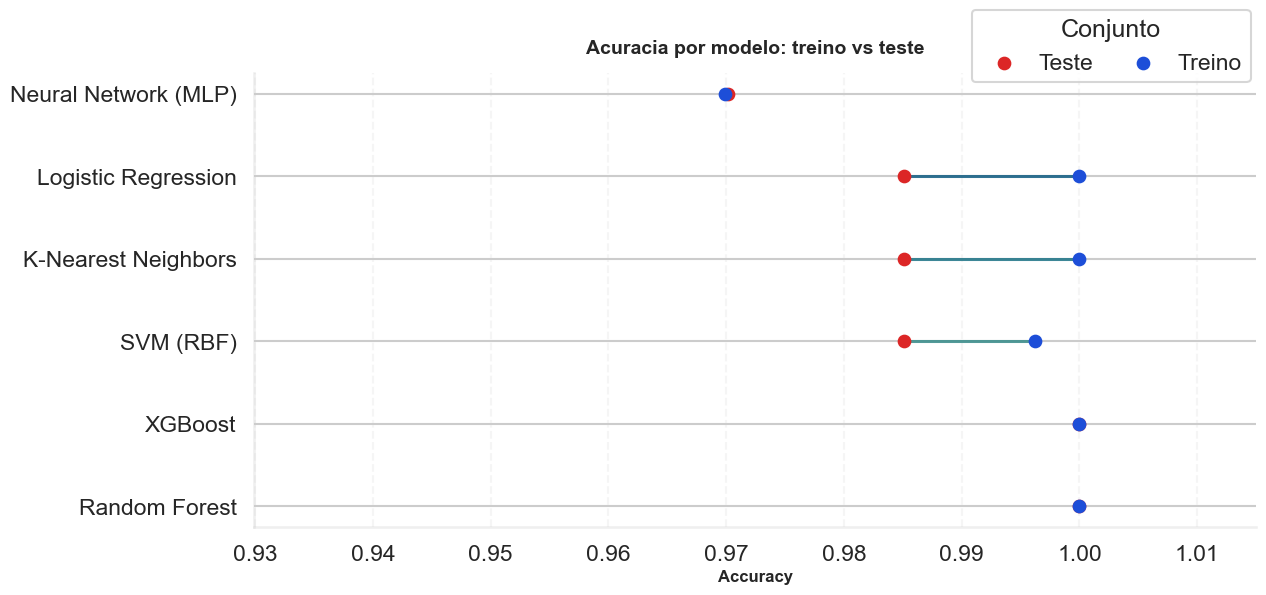

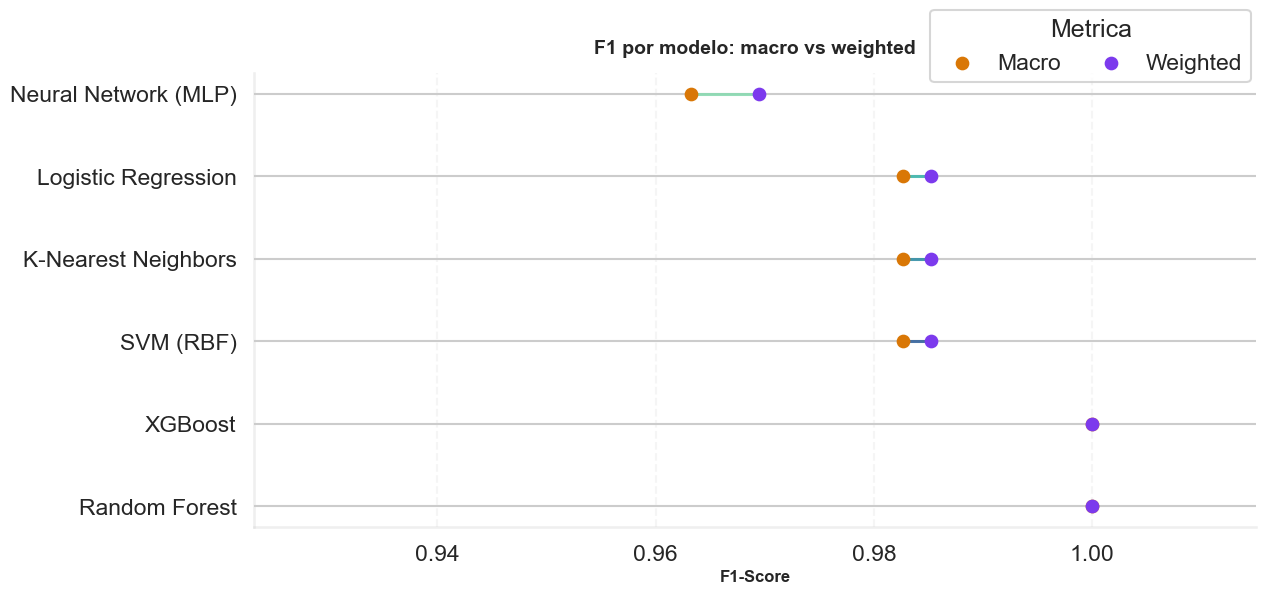

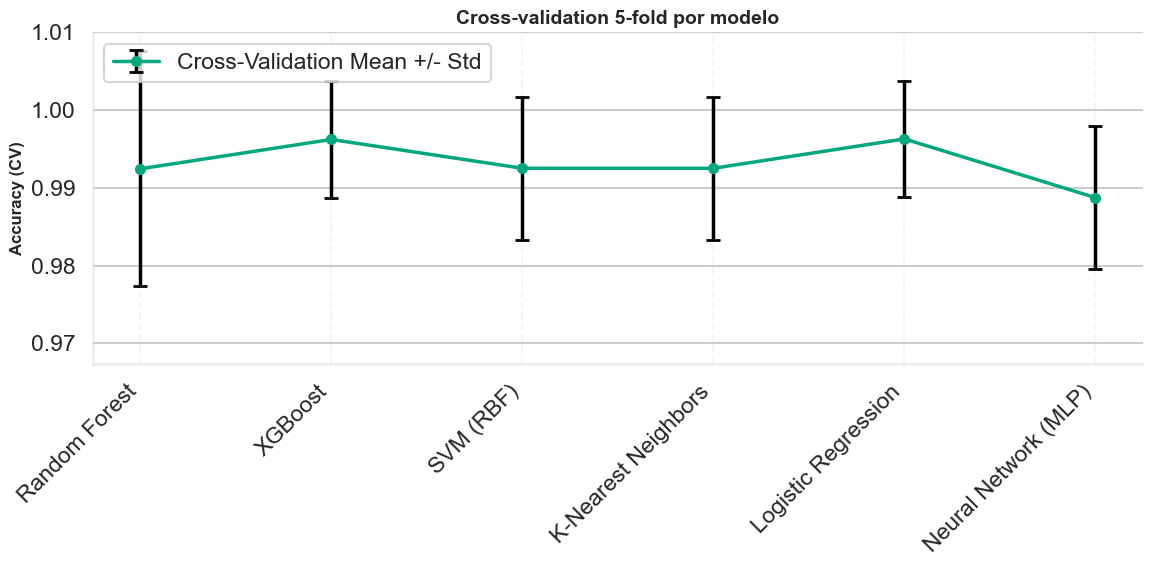

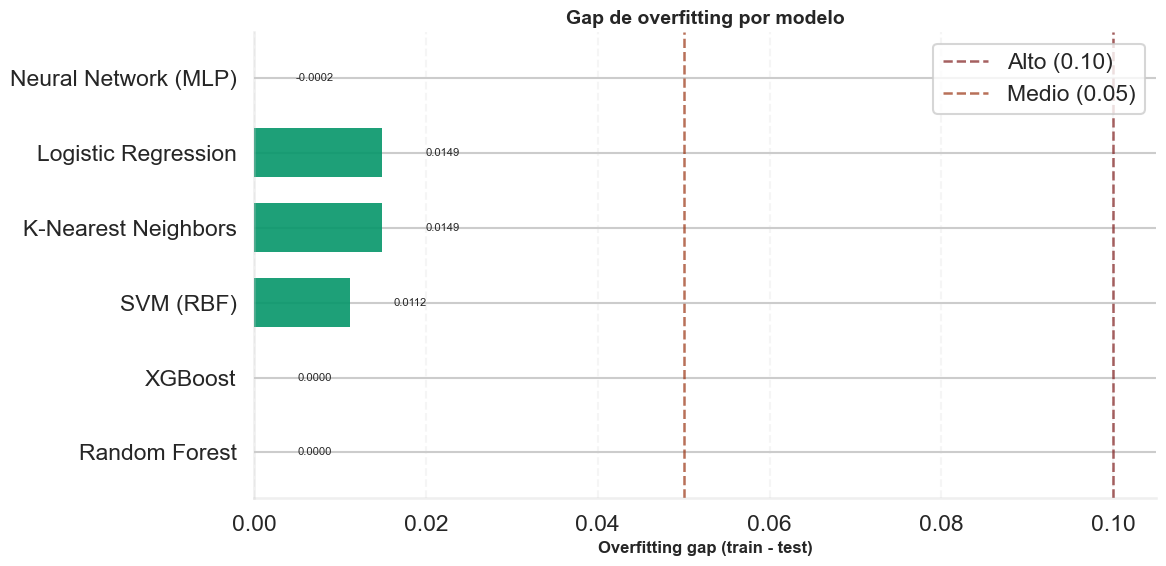

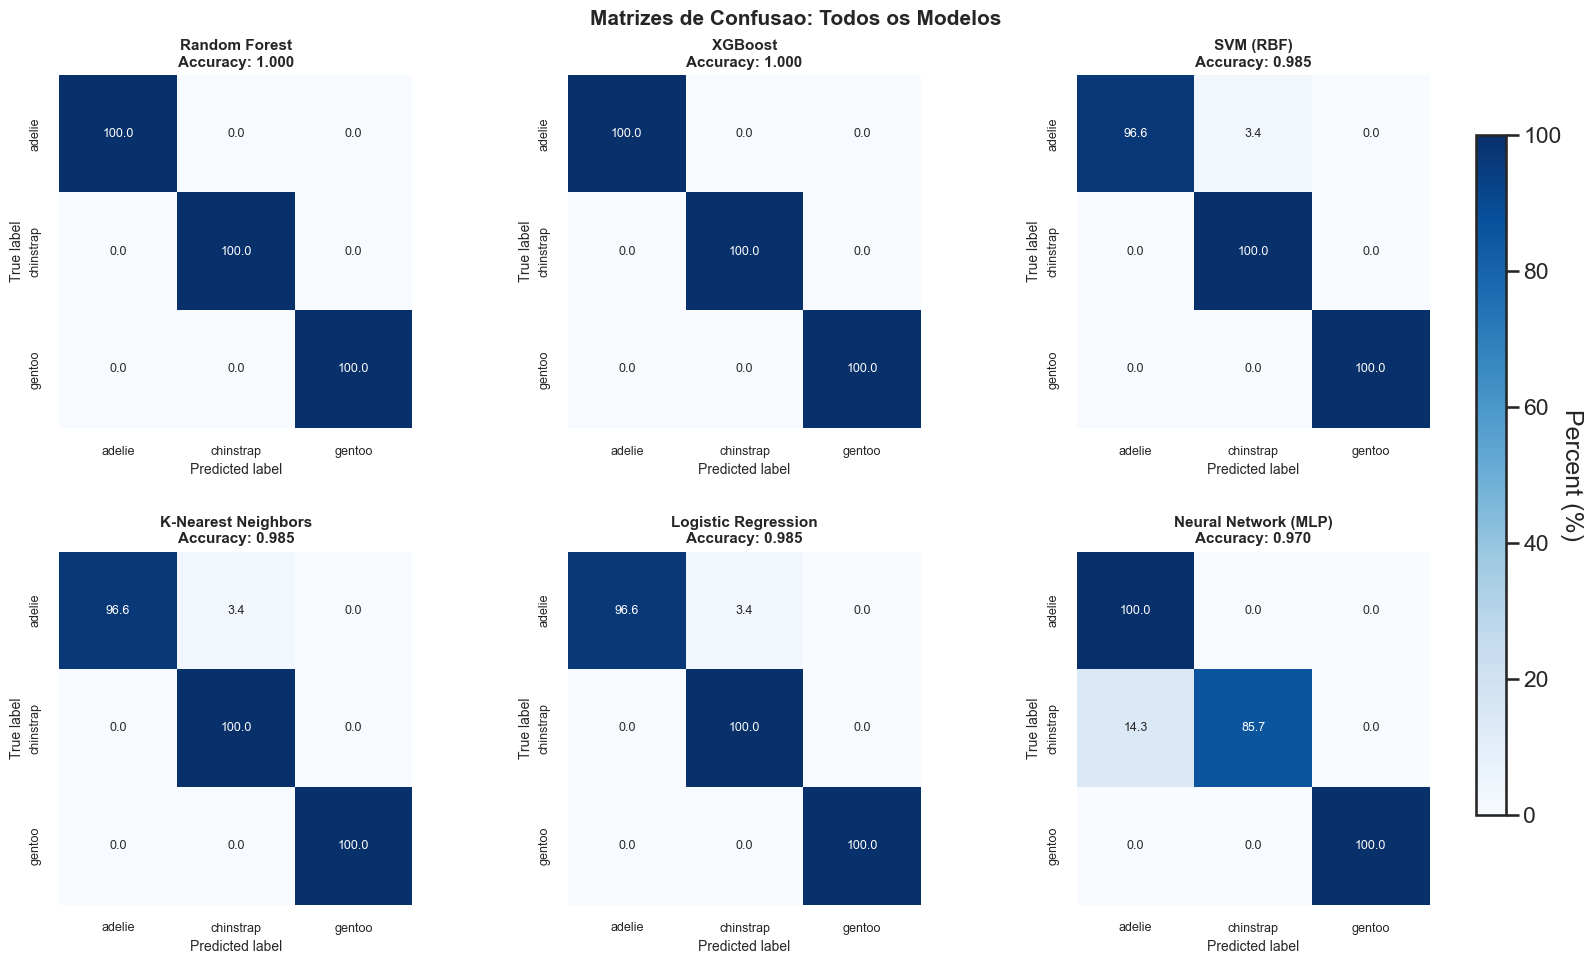

In [11]:
plot_comparison_inline(evaluator.results)
plot_confusion_matrices_inline(evaluator.results, class_names)

## Etapas 9 e 10 - Salvamento Opcional

In [12]:
SAVE_ARTIFACTS = False

if SAVE_ARTIFACTS:
    Path("models").mkdir(exist_ok=True)

    for model_key, model in models_manager.trained_models.items():
        filepath = f"models/{model_key}.pkl"
        joblib.dump(model, filepath)
        print(f"{models_manager.models[model_key]['name']} -> {filepath}")

    preprocessing_data = {
        "scaler": data["scaler"],
        "label_encoder": data["label_encoder"],
        "feature_names": feature_names,
        "class_names": class_names,
        "metadata": data["metadata"],
    }

    joblib.dump(preprocessing_data, "models/preprocessing.pkl")
    print("Preprocessadores salvos em models/preprocessing.pkl")
else:
    print("SAVE_ARTIFACTS=False -> artefatos nao foram salvos (somente visualizacao inline).")

SAVE_ARTIFACTS=False -> artefatos nao foram salvos (somente visualizacao inline).
